# Radar
Please read the `README.md` file before running this tutorial.

This tutorial shows some basic radar data accessing and helper functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from pyboreas import BoreasDataset
from pyboreas.utils.utils import get_inverse_tf

root = '/home/dl/Documents/phd/data/boreas/'
split = [['boreas-2024-12-03-12-54']]
# AWS: Note: Free Tier SageMaker instances don't have enough storage (25 GB) for 1 sequence (100 GB)
# root = '/home/ec2-user/SageMaker/boreas/'
# split = [['boreas-2021-09-02-11-42', 163059759e6, 163059760e6-1]]

# With verbose=True, the following will print information about each sequence
bd = BoreasDataset(root, split=split, verbose=True)
# Grab the first sequence
seq = bd.sequences[0]

SEQ: boreas-2024-12-03-12-54
camera frames: 9860
lidar frames: 9480
radar frames: 3948
aeva frames: 9860
dmu frames: 0
aeva imu frames: 0
encoder frames: 0
-------------------------------
total aeva frames: 9860
total camera frames: 9860
total lidar frames: 9480
total radar frames: 3948
total dmu frames: 0
total aeva imu frames: 0
total encoder frames: 0


In [2]:
# Radar is calibrated to other sensors through the Velodyne lidar
T_radar_lidar = seq.calib.T_radar_lidar
print('T_radar_lidar:\n', T_radar_lidar)
T_radar_applanix = T_radar_lidar @ get_inverse_tf(seq.calib.T_applanix_lidar)
print('T_radar_applanix:\n', T_radar_applanix)

T_radar_lidar:
 [[ 0.675239  0.737599  0.        0.      ]
 [ 0.737599 -0.675239  0.        0.      ]
 [ 0.        0.       -1.        0.365   ]
 [ 0.        0.        0.        1.      ]]
T_radar_applanix:
 [[-0.00389678  0.9999922   0.          0.        ]
 [ 0.9999922   0.00389678  0.          0.        ]
 [ 0.          0.         -1.          0.495     ]
 [ 0.          0.          0.          1.        ]]


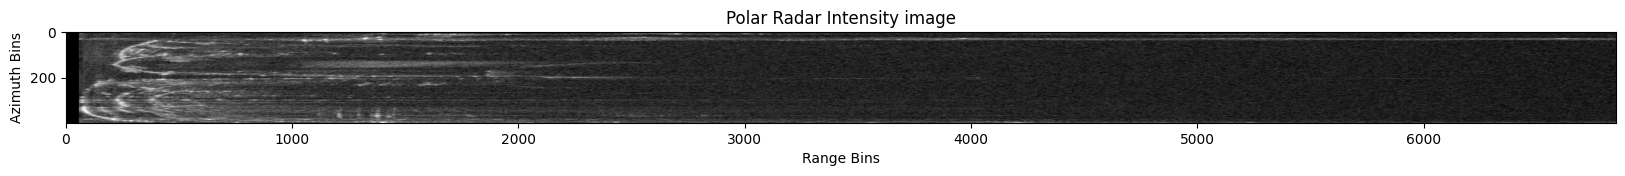

In [ ]:
# The raw radar data is contained within a polar image.
# Note that the first 2.5 meters of the radar image are zeroed out by default
# to remove noise from the vehicle itself.

rad = seq.get_radar(0)
plt.figure(figsize=(20, 100))
polar_img = plt.imshow(rad.polar, cmap="gray")
plt.title("Polar Radar Intensity image")
plt.xlabel("Range Bins")
plt.ylabel("Azimuth Bins")
plt.show()

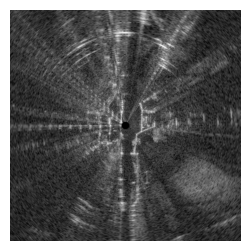

In [14]:
# A more intuitive visualization is achieved through converting the polar image to a Cartesian image
# The radar visualizer plots this Cartesian image.
# Take a look inside the visualizer to see how the radar data gets converted to a Cartesian image
# There are also other options, including saving the cartesian image:
# rad.visualize(figsize=(5, 5), save='/path/to/saved/image/radar.png')

rad = seq.get_radar(0)
cart_img = rad.visualize(figsize=(3, 3))


In [5]:
# Note that each sensor frame has a timestamp, pose (4x4 homogeneous transform), and velocity information.
rad = seq.get_lidar(0)
print('Radar:')
print('timestamp: {}'.format(rad.timestamp))
print('pose (T_enu_lidar):')
print(rad.pose)
print('velocity (wrt ENU):')
print(rad.velocity)
print('body rate (wrt sensor):')
print(rad.body_rate)

# Note that lidar and camera frames are collected at 10Hz, but radar frames collected at 4 Hz.

Radar:
timestamp: 1733248461.9866939
pose (T_enu_lidar):
[[ 8.29192332e-01  5.58589944e-01 -2.04291531e-02 -3.46169604e+00]
 [-5.58963220e-01  8.28666905e-01 -2.95174389e-02  1.08686851e+00]
 [ 4.40818531e-04  3.58947793e-02  9.99355478e-01  1.51050761e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
velocity (wrt ENU):
[[-0.00014893]
 [-0.00147241]
 [-0.00170809]
 [ 0.00026263]
 [ 0.00071255]
 [ 0.00127652]]
body rate (wrt sensor):
[[ 0.00069878]
 [-0.00136463]
 [-0.00166048]
 [-0.00017995]
 [ 0.00078299]
 [ 0.0012493 ]]


In [23]:
# Each radar azimuth contains its own timestamp
# The radar frame timestamp corresponds to the middle of the frame
print('Radar at frame timestamp {} has {} azimuths.'.format(rad.timestamp_micro, len(rad.azimuths)))
print('Timestamps of the middle 5 azimuths:')
print(rad.timestamps[len(rad.azimuths) // 2 - 3: len(rad.azimuths) // 2 + 2])


Radar at frame timestamp 1733248462079298 has 400 azimuths.
Timestamps of the middle 5 azimuths:
[[1733248462078048]
 [1733248462078673]
 [1733248462079298]
 [1733248462079923]
 [1733248462080548]]


In [24]:
# Example: using an iterator
rad_iter = bd.sequences[0].get_radar_iter()
rad0 = next(rad_iter)  # First camera frame
rad1 = next(rad_iter)  # Second camera frame
print(rad0.timestamp)
print(rad1.timestamp)

1733248462.079298
1733248462.329001
